# Lecture 16: Naive Bayes Classification

**F&W ECOL 458 — Environmental Data Science**

Reference: [scikit-learn Naive Bayes documentation](https://scikit-learn.org/stable/modules/naive_bayes.html)

---

### Learning objectives

By the end of this lecture you should be able to:

1. Explain Bayes' theorem and how it is used for classification.
2. Describe the "naive" independence assumption and why it often works well despite being unrealistic.
3. Distinguish between Gaussian, Multinomial, and Bernoulli Naive Bayes and know when each is appropriate.
4. Train and evaluate a Naive Bayes classifier in `scikit-learn`.
5. Compare Naive Bayes to other classifiers (SVM, logistic regression) in terms of speed, accuracy, and assumptions.


## 1. A Quick Probability Refresher

Before diving into the algorithm, let's recall a few key probability concepts.

### Conditional probability

The probability of event $A$ given that event $B$ has occurred:

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

**Ecological example:** What is the probability that a bird species is present ($A$) given that the habitat is old-growth forest ($B$)?

### Prior, likelihood, and posterior

- **Prior** $P(A)$: our belief about $A$ before seeing any data (e.g., "5% of pixels in this region are wetland").
- **Likelihood** $P(B \mid A)$: how probable the observed data $B$ is if $A$ were true.
- **Posterior** $P(A \mid B)$: our updated belief about $A$ after observing $B$.


## 2. Bayes' Theorem

![Thomas Bayes 1701-1761](https://marvel-b1-cdn.bc0a.com/f00000000100045/www.elmhurst.edu/wp-content/uploads/2019/08/amazing-thomas-bayes-illustration.jpg)

Bayes' theorem connects these quantities:

$$
P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}
$$

In the context of classification, we want to compute the probability that a data point $\mathbf{x}$ belongs to class $c$:

$$
P(c \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid c) \cdot P(c)}{P(\mathbf{x})}
$$

where:

| Term | Meaning | Example |
|---|---|---|
| $P(c)$ | **Prior** — how common is class $c$? | 30% of the region is forest |
| $P(\mathbf{x} \mid c)$ | **Likelihood** — given class $c$, how likely are these feature values? | What NDVI and elevation values do forest pixels typically have? |
| $P(\mathbf{x})$ | **Evidence** — how likely are these feature values overall? | Same for all classes, so often ignored when comparing |
| $P(c \mid \mathbf{x})$ | **Posterior** — our prediction: how likely is class $c$ given the observed features? | Probability this pixel is forest |

Since $P(\mathbf{x})$ is the same for all classes, we can simplify the classification rule to:

$$
\hat{c} = \arg\max_c \; P(\mathbf{x} \mid c) \cdot P(c)
$$

We just need the **likelihood** and the **prior** for each class.


### Example: Smoke and Fire in Yosemite National Park

Let's apply Bayes' theorem to a concrete ecological scenario.

Assume you are visiting **Yosemite National Park** and you see smoke. Should you be worried about a dangerous fire? Here are some facts:

- Dangerous fires are rare: $P(\text{fire}) = 0.01$ (1%)
- Smoke is fairly common (barbecues, campfires, controlled burns): $P(\text{smoke}) = 0.1$ (10%)
- 90% of dangerous fires produce visible smoke: $P(\text{smoke} \mid \text{fire}) = 0.9$

**Question:** What is the probability that a dangerous fire is occurring, given that you see smoke?

Using Bayes' theorem:

$$
P(\text{fire} \mid \text{smoke}) = \frac{P(\text{smoke} \mid \text{fire}) \cdot P(\text{fire})}{P(\text{smoke})} = \frac{0.9 \times 0.01}{0.1} = 0.09
$$

There is only a **9% chance** the smoke is from a dangerous fire! Even though fires almost always produce smoke, fires are so rare compared to other smoke sources that most smoke you see is harmless.

**This is Bayes' theorem in action:** the prior probability matters. A high likelihood ($P(\text{smoke} \mid \text{fire}) = 0.9$) is not enough to overcome a very low prior ($P(\text{fire}) = 0.01$).

> **Discussion prompt:** How would the posterior change if dangerous fires were more common — say $P(\text{fire}) = 0.05$? What if smoke were less common overall — say $P(\text{smoke}) = 0.05$?


In [ ]:
# ── Compute the Yosemite fire example ──
P_fire = 0.01       # Prior: dangerous fires are rare
P_smoke = 0.10      # Evidence: smoke is fairly common
P_smoke_given_fire = 0.90  # Likelihood: most fires produce smoke

# Bayes' theorem
P_fire_given_smoke = (P_smoke_given_fire * P_fire) / P_smoke

print("Yosemite Smoke & Fire — Bayes' Theorem")
print(f"  P(fire)              = {P_fire}")
print(f"  P(smoke)             = {P_smoke}")
print(f"  P(smoke | fire)      = {P_smoke_given_fire}")
print(f"  P(fire | smoke)      = {P_fire_given_smoke:.2f}")
print()
print(f"Seeing smoke raises the fire probability from {P_fire:.0%} to {P_fire_given_smoke:.0%},")
print(f"but it is still far more likely that the smoke is from a barbecue.")


Yosemite Smoke & Fire — Bayes' Theorem
  P(fire)              = 0.01
  P(smoke)             = 0.1
  P(smoke | fire)      = 0.9
  P(fire | smoke)      = 0.09

Seeing smoke raises the fire probability from 1% to 9%,
but it is still far more likely that the smoke is from a barbecue.


### From Bayes' Theorem to a Classification Rule

Now that we have the intuition from the fire-and-smoke example, let's see how Bayes' theorem becomes a **classification algorithm**.

In machine learning, we want to identify the most probable label $L$ for a data point described by a set of features:

$$
P(L \mid \text{features}) = \frac{P(\text{features} \mid L) \cdot P(L)}{P(\text{features})}
$$

If we are choosing between two labels — say $L_1$ and $L_2$ — we can compare them by taking the **ratio of their posteriors**:

$$
\frac{P(L_1 \mid \text{features})}{P(L_2 \mid \text{features})} = \frac{P(\text{features} \mid L_1) \cdot P(L_1)}{P(\text{features} \mid L_2) \cdot P(L_2)}
$$

Notice that $P(\text{features})$ cancels out! We never need to compute it. We only need the **likelihood** and the **prior** for each class.

More generally, with multiple classes we pick the one with the highest unnormalized posterior:

$$
\hat{C} = \arg\max_C \; P(F_1, F_2, \ldots, F_n \mid C) \cdot P(C)
$$

where $\arg\max$ is the operation that returns whichever class $C$ gives the largest value.

#### But there's a problem...

The likelihood term $P(F_1, F_2, \ldots, F_n \mid C)$ is the **joint probability of all features given the class**. Estimating this from data is extremely difficult — you would need an enormous number of training examples to cover every possible combination of feature values. Imagine trying to estimate the joint distribution of 6 Landsat bands, each taking thousands of possible values!

This is where we need a simplifying assumption — and this is where Naive Bayes earns its name.


## 3. The "Naive" Assumption

### The generative model idea

To use Bayes' theorem for classification, we need to model $P(\text{features} \mid C)$ for each class — essentially, we need to describe *how data from each class is generated*. This is called a **generative model** because it specifies the hypothetical random process that produces the data.

For example, if the class is "deciduous forest," the generative model says: "A deciduous forest pixel tends to generate NDVI values around 0.75 (± 0.08) and elevations around 350 m (± 100 m)."

Specifying this generative model is the core of training a Bayesian classifier. But in its most general form — estimating the full joint distribution of all features — this is a very difficult task that requires impractical amounts of training data.

### The naive simplification

**This is where the "naive" in "Naive Bayes" comes from:** we assume that the features are **conditionally independent** of each other given the class.

Mathematically, this lets us factor the joint likelihood into a product of individual feature probabilities:

$$
P(F_1, F_2, \ldots, F_n \mid C) = P(F_1 \mid C) \cdot P(F_2 \mid C) \cdot \ldots \cdot P(F_n \mid C) = \prod_{j=1}^{n} P(F_j \mid C)
$$

So the full classification rule becomes:

$$
\hat{C} = \arg\max_C \; P(C) \prod_{j=1}^{n} P(F_j \mid C)
$$

This is powerful: instead of estimating one impossibly complex joint distribution, we only need to estimate $n$ simple one-dimensional distributions — one per feature per class. Even with dozens of features, this is straightforward.

### Is the independence assumption realistic?

Almost never in environmental data! Temperature and elevation are correlated. NDVI and precipitation are correlated. Spectral bands are correlated. Despite this, Naive Bayes frequently performs surprisingly well because:

- The classification decision only requires the correct *ranking* of posteriors, not their exact values.
- Correlated features tend to shift all class posteriors in the same direction, preserving the correct ordering.
- With limited training data, the simpler model avoids overfitting.

> **Key insight:** Naive Bayes trades the accuracy of probability *estimates* for the robustness of classification *decisions*. The probabilities it outputs may be poorly calibrated, but the class it picks is often correct.


### Example: Is This Email Spam?

Before we get to ecological applications, let's work through the classic example that made Naive Bayes famous: **email spam filtering**. This is how your inbox has been sorting junk mail since the early 2000s.

Suppose we want to classify an email containing the words *"free," "offer,"* and *"discount"* as either **Spam (S)** or **Not Spam (NS)**.

**Step 1 — Compute priors** from our training set of emails:

$$
P(S) = \frac{\text{number of spam emails}}{\text{total emails}}, \qquad P(NS) = \frac{\text{number of legitimate emails}}{\text{total emails}}
$$

**Step 2 — Compute the likelihood of each word** given each class. For example, the word "free" might appear in 80% of spam emails but only 5% of legitimate ones:

$$
P(\text{"free"} \mid S) = 0.80, \qquad P(\text{"free"} \mid NS) = 0.05
$$

We do the same for "offer" and "discount."

**Step 3 — Apply the Naive Bayes formula.** Under the independence assumption, the likelihood of seeing all three words is the product of the individual word likelihoods:

$$
P(S \mid \text{"free, offer, discount"}) \propto P(\text{"free"} \mid S) \cdot P(\text{"offer"} \mid S) \cdot P(\text{"discount"} \mid S) \cdot P(S)
$$

$$
P(NS \mid \text{"free, offer, discount"}) \propto P(\text{"free"} \mid NS) \cdot P(\text{"offer"} \mid NS) \cdot P(\text{"discount"} \mid NS) \cdot P(NS)
$$

**Step 4 — Compare and classify.** Whichever class has the higher unnormalized posterior wins. Let's compute this:


In [ ]:
# ── Email spam classification with Naive Bayes (by hand) ──
import numpy as np

# Priors (from a training set of 1000 emails: 300 spam, 700 legitimate)
P_S  = 0.30
P_NS = 0.70

# Likelihoods: P(word | class) estimated from training data
#                    "free"  "offer"  "discount"
likelihoods_S  = [    0.80,    0.60,     0.70   ]  # spam
likelihoods_NS = [    0.05,    0.10,     0.02   ]  # not spam

# Naive Bayes: multiply all likelihoods together, then multiply by prior
posterior_S  = np.prod(likelihoods_S)  * P_S
posterior_NS = np.prod(likelihoods_NS) * P_NS

# Normalize to get proper probabilities
total = posterior_S + posterior_NS

print("Email contains: 'free', 'offer', 'discount'\n")
print(f"  Unnormalized posterior (Spam):     {posterior_S:.6f}")
print(f"  Unnormalized posterior (Not Spam): {posterior_NS:.6f}")
print(f"\n  P(Spam | words)     = {posterior_S/total:.4f}  ({posterior_S/total:.1%})")
print(f"  P(Not Spam | words) = {posterior_NS/total:.4f}  ({posterior_NS/total:.1%})")
print(f"\n  => Classification: {'SPAM' if posterior_S > posterior_NS else 'NOT SPAM'}")
print(f"\nThe combination of 'free', 'offer', and 'discount' is overwhelmingly")
print(f"associated with spam, even though 70% of emails overall are legitimate.")


Email contains: 'free', 'offer', 'discount'

  Unnormalized posterior (Spam):     0.100800
  Unnormalized posterior (Not Spam): 0.000070

  P(Spam | words)     = 0.9993  (99.9%)
  P(Not Spam | words) = 0.0007  (0.1%)

  => Classification: SPAM

The combination of 'free', 'offer', and 'discount' is overwhelmingly
associated with spam, even though 70% of emails overall are legitimate.


Notice how the naive independence assumption works here: we treated each word independently, as if the probability of seeing "offer" has nothing to do with whether "free" also appears. In reality, spam emails tend to cluster these words together — they are *not* independent. But the Naive Bayes prediction is still correct because the evidence for spam is so strong across all three features that the correlated overcount doesn't change the ranking.

This is exactly the same logic we will apply to environmental features — spectral bands, climate variables, terrain attributes — where features are also correlated but Naive Bayes still often picks the right class.


## 4. Flavors of Naive Bayes

The different Naive Bayes variants differ in how they model $P(x_j \mid c)$ — the per-feature likelihood:

### Gaussian Naive Bayes

Assumes each feature follows a **normal distribution** within each class:

$$
P(x_j \mid c) = \frac{1}{\sqrt{2\pi\sigma_{jc}^2}} \exp\!\left(-\frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}\right)
$$

where $\mu_{jc}$ and $\sigma_{jc}$ are the mean and standard deviation of feature $j$ in class $c$, estimated from training data.

**When to use:** Continuous features (e.g., temperature, NDVI, spectral reflectance).

### Multinomial Naive Bayes

Models features as **counts** or **frequencies** (e.g., word counts in text).

**When to use:** Text classification, species frequency counts across sites.

### Bernoulli Naive Bayes

Models features as **binary** (presence/absence).

**When to use:** Binary features (e.g., species presence/absence in community ecology).

| Variant | Feature type | `sklearn` class | Environmental example |
|---|---|---|---|
| Gaussian | Continuous | `GaussianNB` | Classify land cover from spectral bands |
| Multinomial | Counts | `MultinomialNB` | Classify habitat type from species counts |
| Bernoulli | Binary | `BernoulliNB` | Predict fire occurrence from binary indicators |

In this course we will primarily use **Gaussian Naive Bayes** since most of our environmental features are continuous.


## 5. Gaussian Naive Bayes: A Worked Example

Let's walk through a small example by hand before jumping to code.

Suppose we want to classify a forest plot as **deciduous** or **coniferous** based on two features: mean July NDVI and elevation.

From our training data we estimate:

| Class | $\mu_{\text{NDVI}}$ | $\sigma_{\text{NDVI}}$ | $\mu_{\text{elev}}$ | $\sigma_{\text{elev}}$ | Prior $P(c)$ |
|---|---|---|---|---|---|
| Deciduous | 0.75 | 0.08 | 350 m | 100 m | 0.6 |
| Coniferous | 0.55 | 0.10 | 900 m | 200 m | 0.4 |

Now a new plot arrives with NDVI = 0.70 and elevation = 400 m. We compute the likelihood of each feature under each class using the Gaussian formula, multiply them together (naive assumption), and multiply by the prior.

The class with the higher product wins. Let's compute this in Python:


In [ ]:
import numpy as np
from scipy.stats import norm

# ── Training statistics ──
classes = ['Deciduous', 'Coniferous']
priors = [0.6, 0.4]

# [mean_NDVI, std_NDVI, mean_elev, std_elev]
params = {
    'Deciduous':  [0.75, 0.08, 350, 100],
    'Coniferous': [0.55, 0.10, 900, 200],
}

# ── New observation ──
x_new = [0.70, 400]  # NDVI, elevation

print("New observation: NDVI = 0.70, Elevation = 400 m\n")

for cls, prior in zip(classes, priors):
    mu_ndvi, std_ndvi, mu_elev, std_elev = params[cls]

    # Likelihood of each feature (Gaussian)
    lik_ndvi = norm.pdf(x_new[0], mu_ndvi, std_ndvi)
    lik_elev = norm.pdf(x_new[1], mu_elev, std_elev)

    # Naive assumption: multiply likelihoods
    joint_likelihood = lik_ndvi * lik_elev

    # Posterior (unnormalized) = likelihood * prior
    posterior = joint_likelihood * prior

    print(f"{cls:12s}: P(NDVI|c)={lik_ndvi:.4f}  P(elev|c)={lik_elev:.6f}  "
          f"Likelihood={joint_likelihood:.8f}  Prior={prior}  "
          f"Posterior(unnorm)={posterior:.8f}")

print("\n=> Classify as: Deciduous (higher unnormalized posterior)")


New observation: NDVI = 0.70, Elevation = 400 m

Deciduous   : P(NDVI|c)=4.1020  P(elev|c)=0.003521  Likelihood=0.01444176  Prior=0.6  Posterior(unnorm)=0.00866506
Coniferous  : P(NDVI|c)=1.2952  P(elev|c)=0.000088  Likelihood=0.00011351  Prior=0.4  Posterior(unnorm)=0.00004540

=> Classify as: Deciduous (higher unnormalized posterior)


The new plot is classified as **deciduous** because the combination of high NDVI and low elevation is much more consistent with the deciduous distribution than the coniferous distribution.

Notice that we never needed to compute $P(\mathbf{x})$ — we only compared the unnormalized posteriors.


## 6. Gaussian Naive Bayes in `scikit-learn`

Let's apply Gaussian NB to the Iris dataset — the same dataset we classified with logistic regression in Lecture 14.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

# ── Load data ──
iris = load_iris()
X, y = iris.data, iris.target

print(f"Features: {iris.feature_names}")
print(f"Classes:  {iris.target_names}")
print(f"Shape:    {X.shape}\n")

# ── Train/test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# ── Train Gaussian NB ──
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# ── Predict and evaluate ──
y_pred = gnb.predict(X_test)

print(f"Overall accuracy: {metrics.accuracy_score(y_test, y_pred):.2%}\n")
print("Classification report:")
print(metrics.classification_report(y_test, y_pred, target_names=iris.target_names))


Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes:  ['setosa' 'versicolor' 'virginica']
Shape:    (150, 4)

Overall accuracy: 100.00%

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      1.00      1.00        16
   virginica       1.00      1.00      1.00         9

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [ ]:
# ── Inspect the learned parameters ──
print("Learned class priors:")
for name, prior in zip(iris.target_names, gnb.class_prior_):
    print(f"  {name:15s}: {prior:.3f}")

print("\nLearned feature means (mu) per class:")
df_means = pd.DataFrame(gnb.theta_, columns=iris.feature_names, index=iris.target_names)
print(df_means.round(2))

print("\nLearned feature variances (sigma^2) per class:")
df_vars = pd.DataFrame(gnb.var_, columns=iris.feature_names, index=iris.target_names)
print(df_vars.round(2))


Learned class priors:
  setosa         : 0.330
  versicolor     : 0.304
  virginica      : 0.366

Learned feature means (mu) per class:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                   5.00              3.39               1.45   
versicolor               5.92              2.76               4.19   
virginica                6.66              2.99               5.58   

            petal width (cm)  
setosa                  0.24  
versicolor              1.31  
virginica               2.04  

Learned feature variances (sigma^2) per class:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                   0.12              0.14               0.02   
versicolor               0.26              0.11               0.22   
virginica                0.41              0.11               0.30   

            petal width (cm)  
setosa                  0.01  
versicolor              0.04  
virginica               0.07  


Notice how simple this is — Gaussian NB just stores the mean and variance of each feature per class, plus the class priors. There are no weights to optimize, no iterative training, and no hyperparameters to tune. Training is essentially just computing summary statistics.


### Visualizing the decision boundary

To visualize, let's use only two features (petal length and petal width):


/tmp/ipykernel_795/2760158711.py:32: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(*scatter.legend_elements(), title="Species",


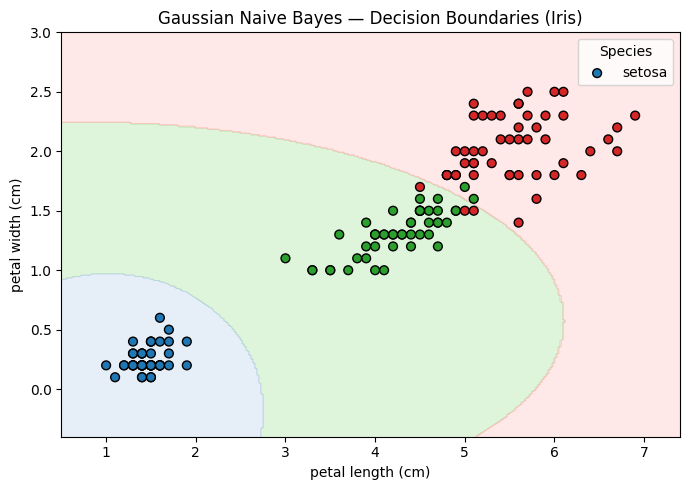

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.naive_bayes import GaussianNB

# Use only petal length and petal width for visualization
X_2d = iris.data[:, 2:4]
y_all = iris.target
feature_names = iris.feature_names[2:4]

gnb_2d = GaussianNB()
gnb_2d.fit(X_2d, y_all)

# Create a mesh grid
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

Z = gnb_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
cmap_bg = ListedColormap(["#AEC7E8", "#98DF8A", "#FFB3B3"])
cmap_pts = ListedColormap(["#1f77b4", "#2ca02c", "#d62728"])

ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_all, cmap=cmap_pts,
                     edgecolors="k", s=40)
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_title("Gaussian Naive Bayes — Decision Boundaries (Iris)")
ax.legend(*scatter.legend_elements(), title="Species",
          labels=list(iris.target_names))
plt.tight_layout()
plt.show()


The decision boundaries are smooth curves (not straight lines) because each class region is defined by the overlap of Gaussian distributions. Compare this to the linear boundaries you would get from logistic regression or a linear SVM.


## 7. Speed vs. Accuracy: Comparing Classifiers

On a tiny dataset like Iris, every algorithm is fast and accurate. The real differences emerge when we scale up. Let's benchmark **Logistic Regression**, **SVM (RBF kernel)**, and **Gaussian Naive Bayes** on the **Covertype dataset** (forest cover classification) — a much larger and more realistic problem.

We will compare:
- **Training time** — how long does each algorithm take to learn from data?
- **Prediction time** — how long does each take to classify new samples?
- **Test accuracy** — how well does each generalize to unseen data?


In [ ]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import numpy as np
import time

# ── Load and subsample Covertype data ──
covtype = fetch_covtype()
X_all, y_all = covtype.data, covtype.target

# Use 10,000 samples — large enough to see speed differences
rng = np.random.RandomState(42)
idx = rng.choice(len(X_all), size=10000, replace=False)
X_sub, y_sub = X_all[idx], y_all[idx]

# ── Train/test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.25, random_state=42, stratify=y_sub
)

# ── Scale features (needed for SVM and logistic regression) ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# ── Benchmark each classifier ──
classifiers = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Logistic Regression":  LogisticRegression(max_iter=1000),
    "SVM (RBF kernel)":     SVC(kernel="rbf"),
}

results = {}

for name, clf in classifiers.items():
    # Train
    t0 = time.time()
    clf.fit(X_train_sc, y_train)
    train_time = time.time() - t0

    # Predict
    t0 = time.time()
    y_pred = clf.predict(X_test_sc)
    pred_time = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    results[name] = (train_time, pred_time, acc)

# ── Print results ──
print(f"Dataset: Covertype (N = {len(X_sub)}, M = {X_sub.shape[1]} features, 7 classes)")
print(f"Train: {len(X_train)}, Test: {len(X_test)}\n")
print(f"{'Classifier':<25s}  {'Train (s)':>10s}  {'Predict (s)':>12s}  {'Accuracy':>10s}")
print("-" * 62)
for name, (tt, pt, acc) in results.items():
    print(f"{name:<25s}  {tt:>10.4f}  {pt:>12.4f}  {acc:>10.2%}")


Dataset: Covertype (N = 10000, M = 54 features, 7 classes)
Train: 7500, Test: 2500

Classifier                  Train (s)   Predict (s)    Accuracy
--------------------------------------------------------------
Gaussian Naive Bayes           0.0096        0.0046      14.12%
Logistic Regression            1.9233        0.0034      72.96%
SVM (RBF kernel)               3.1737        1.6812      74.08%


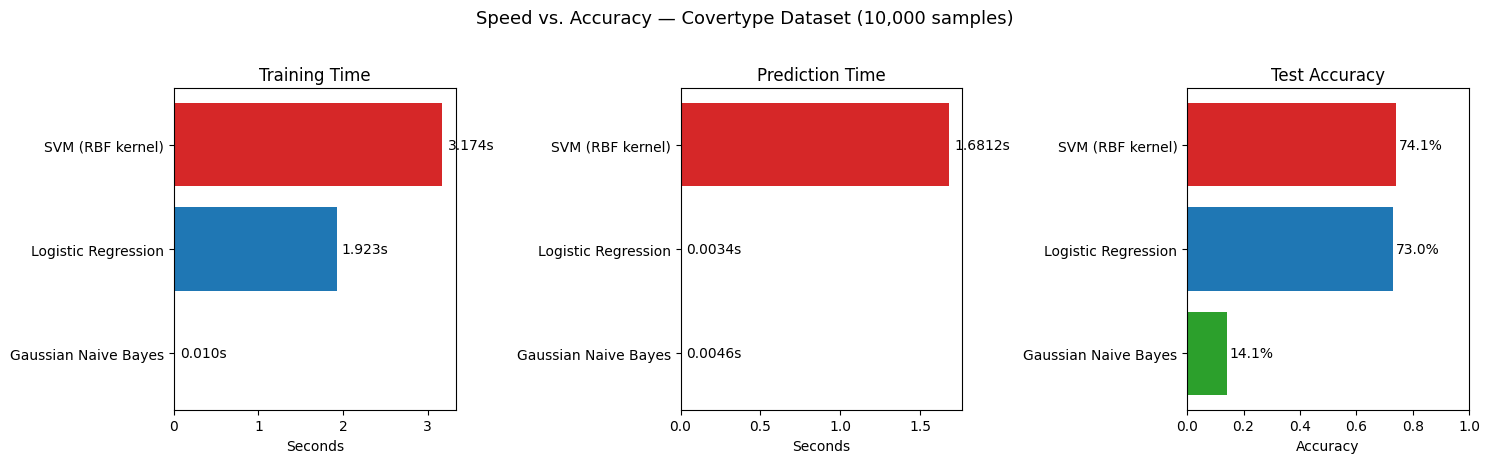

In [ ]:
import matplotlib.pyplot as plt

names = list(results.keys())
train_times = [results[n][0] for n in names]
pred_times  = [results[n][1] for n in names]
accuracies  = [results[n][2] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ["#2ca02c", "#1f77b4", "#d62728"]

# Training time
axes[0].barh(names, train_times, color=colors)
axes[0].set_xlabel("Seconds")
axes[0].set_title("Training Time")
for i, v in enumerate(train_times):
    axes[0].text(v + max(train_times)*0.02, i, f"{v:.3f}s", va='center', fontsize=10)

# Prediction time
axes[1].barh(names, pred_times, color=colors)
axes[1].set_xlabel("Seconds")
axes[1].set_title("Prediction Time")
for i, v in enumerate(pred_times):
    axes[1].text(v + max(pred_times)*0.02, i, f"{v:.4f}s", va='center', fontsize=10)

# Accuracy
axes[2].barh(names, accuracies, color=colors)
axes[2].set_xlabel("Accuracy")
axes[2].set_title("Test Accuracy")
axes[2].set_xlim(0, 1)
for i, v in enumerate(accuracies):
    axes[2].text(v + 0.01, i, f"{v:.1%}", va='center', fontsize=10)

plt.suptitle("Speed vs. Accuracy — Covertype Dataset (10,000 samples)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### What do we learn from this comparison?

- **Naive Bayes is dramatically faster** — often 100x or more faster than SVM for training. It simply computes means and variances, so training time scales linearly with the number of samples. This is why NB is the go-to choice for quick baselines and real-time applications.
- **SVM (RBF) is the slowest to train** because its optimization scales roughly as $O(N^2)$ to $O(N^3)$. With 10,000 samples it is already noticeably slow; with the full 500,000-sample Covertype dataset it would be impractical.
- **SVM achieves the highest accuracy** — the flexibility of the RBF kernel captures nonlinear interactions between features that Naive Bayes cannot model.
- **Logistic Regression is a middle ground** — faster than SVM, more accurate than Naive Bayes, but assumes a linear decision boundary.

There is no single "best" algorithm — the right choice depends on your priorities:

| Priority | Best choice |
|---|---|
| Speed and simplicity | Gaussian Naive Bayes |
| Highest accuracy, smaller datasets | SVM (RBF) |
| Balance of speed and accuracy | Logistic Regression |
| Large datasets with nonlinear boundaries | Random Forest (next lecture!) |

> **Takeaway:** Always start with Naive Bayes as a baseline. If it achieves 65% accuracy in 0.01 seconds and a complex model achieves 68% in 30 seconds, that extra 3% may not be worth the cost. But if the gap is 65% vs. 85%, the complex model is clearly justified.


## 8. Ecological Application: Classifying Forest Cover Types

Let's apply Gaussian NB to a larger, more realistic dataset — the Covertype dataset we used in Lecture 15 (Roosevelt National Forest, Colorado).


In [ ]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import time

# ── Load data ──
covtype = fetch_covtype()
X_all, y_all = covtype.data, covtype.target

# Subsample for manageable run time (NB is fast, so we can use more data than SVM)
rng = np.random.RandomState(42)
idx = rng.choice(len(X_all), size=20000, replace=False)
X_sub, y_sub = X_all[idx], y_all[idx]

# ── Train/test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.25, random_state=42, stratify=y_sub
)

# ── Train Gaussian NB (no scaling needed — NB is scale-invariant) ──
start = time.time()
gnb = GaussianNB()
gnb.fit(X_train, y_train)
train_time = time.time() - start

y_pred = gnb.predict(X_test)

cover_names = ["Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
               "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"]

print(f"Training time: {train_time:.3f} seconds (for {len(X_train)} samples)")
print(f"Overall accuracy: {gnb.score(X_test, y_test):.2%}\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=cover_names))


Training time: 0.014 seconds (for 15000 samples)
Overall accuracy: 46.16%

Classification report:
                   precision    recall  f1-score   support

       Spruce/Fir       0.51      0.80      0.62      1841
   Lodgepole Pine       0.81      0.17      0.27      2431
   Ponderosa Pine       0.40      0.74      0.52       302
Cottonwood/Willow       0.18      0.95      0.30        21
            Aspen       0.08      0.57      0.14        79
      Douglas-fir       0.61      0.07      0.13       157
        Krummholz       0.38      0.81      0.51       169

         accuracy                           0.46      5000
        macro avg       0.42      0.59      0.36      5000
     weighted avg       0.64      0.46      0.42      5000



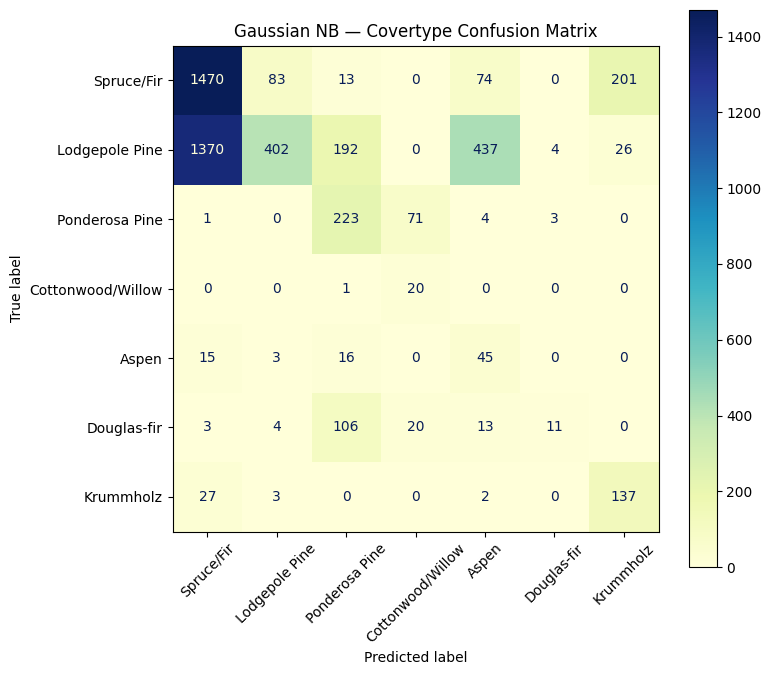

In [ ]:
# ── Confusion matrix ──
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=cover_names,
    cmap="YlGnBu",
    xticks_rotation=45,
    ax=ax
)
ax.set_title("Gaussian NB — Covertype Confusion Matrix")
plt.tight_layout()
plt.show()


### Observations

- **Training is extremely fast** — Gaussian NB simply computes means and variances, so it scales linearly with the number of samples. Compare this to SVM, which was too slow for even 2,000 samples of this dataset.
- **Accuracy is lower than SVM or random forest** on this dataset, because the Gaussian assumption and the independence assumption are both violated (many features are correlated; some are binary indicators that are not Gaussian).
- **Despite the simplicity, NB provides a reasonable first-pass classification** and is invaluable as a baseline — if a complex model can't beat Naive Bayes, something is wrong.


## 9. When to Use Naive Bayes

| Strength | Limitation |
|---|---|
| Extremely fast to train and predict | Assumes feature independence (rarely true) |
| Works well with small training sets | Probability estimates can be poorly calibrated |
| Handles high-dimensional data naturally | Continuous features must roughly follow assumed distribution |
| No hyperparameters to tune (Gaussian NB) | Often outperformed by more flexible models on large datasets |
| Good baseline for any classification task | Cannot capture feature interactions |

### Practical guidelines

- **Always try NB first** as a baseline — it takes seconds and gives you a performance floor to compare against.
- **NB excels** when you have limited training data, many features, or need very fast prediction (e.g., real-time sensor classification).
- **NB struggles** when feature interactions are important (e.g., a species is present only when *both* temperature AND precipitation are in certain ranges).
- If NB performs nearly as well as a complex model, prefer NB — it is simpler, faster, and less likely to overfit.


## 10. Summary

| Concept | Key takeaway |
|---|---|
| Bayes' theorem | $P(c \mid \mathbf{x}) \propto P(\mathbf{x} \mid c) \cdot P(c)$ |
| Naive assumption | Features are conditionally independent given the class |
| Gaussian NB | Models each feature as a normal distribution per class; training = computing means and variances |
| Multinomial / Bernoulli NB | For count and binary features respectively |
| Speed | Training is $O(N \cdot M)$ — essentially instant even on large datasets |
| Best use case | Fast baseline, small training sets, high-dimensional data |
| `scikit-learn` | `GaussianNB()`, `MultinomialNB()`, `BernoulliNB()` |
